# Reading FCS, compensation and display scales

Cytometry is a modality, not a sub-analysis of single-cell RNA-seq. An event is
a cell, but nothing else transfers: the file format is FCS, the values a
detector reports are contaminated by every *other* fluorochrome in the panel,
and the axis you look at is a nonlinear display scale that has to be carried
around with the data or every gate drawn on it becomes meaningless.

`ov.flow` covers those three things, and this notebook is about all three:

1. **reading** — `ov.io.read_fcs`, and what lands in the `AnnData`
2. **compensation** — undoing spillover between detectors
3. **display transforms** — logicle / hyperlog / asinh, and why a log axis is
   not an option

Two later notebooks build on this one: [gating](t_flow_02_gating.ipynb) and
[saving a strategy](t_flow_03_gatingml.ipynb).

## A sample to work on

Everything below runs on `ov.datasets.flow_demo_fcs()`, which writes a
**simulated** FCS file, so there is nothing to download. It is the only
generated dataset in `ov.datasets`; everything else there is real published
data, and the docstring says so loudly for a reason.

Simulated on purpose rather than as a convenience. A real FCS file cannot teach
compensation, because once you only have the file the uncompensated truth is
gone — you cannot show what the spillover *did*. Here the true fluorescence is
known, the spillover is applied deliberately, and the before and after can sit
side by side. The same goes for gating: `obs['population']` carries which
population each event really came from, so a gate can be checked against the
answer instead of against how the plot looks. Real data never comes with that
column, which is the entire difficulty of the field.

It also carries a detector noise floor that pushes dim events **below zero** —
not a detail, but the whole reason the display scales at the end of this
notebook exist.

In [1]:
# No data of your own is needed. ov.datasets.flow_demo_fcs() writes a SIMULATED
# FCS 3.1 file into the current working directory: 59,600 events, nine known
# populations, a real $SPILLOVER keyword, and a detector noise floor that pushes
# dim events below zero — which is why a log display axis will not do.
import numpy as np, pathlib
import omicverse as ov

ov.style()          # omicverse's plotting defaults — call this once, up front

path = ov.datasets.flow_demo_fcs()
print(path)


/Users/fernandozeng/miniforge3/envs/omictest/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.4   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

flow_demo.fcs


## Reading

`ov.io.read_fcs` is I/O, so it lives in `ov.io` — `ov.flow` never becomes a
second reader. Events become observations, channels become variables.

In [2]:
adata = ov.io.read_fcs(path)
adata

AnnData object with n_obs × n_vars = 59600 × 8
    obs: 'sample'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnG', 'PnR'
    uns: 'meta', 'fcs'

The `var` table keeps **both** names. A cytometer records a detector
(`FITC-A`); a person thinks in markers (`CD3`). Losing either one breaks
something: gates written by a collaborator name detectors, and figures name
markers.

`var` is indexed by the marker where the file gave one, with the detector kept
in a column — and both resolve to the same data everywhere in `ov.flow`.

In [3]:
adata.var

           n   channel     marker   PnB         PnE  PnG       PnR
FSC-A      1     FSC-A             None  (0.0, 0.0)  1.0  262144.0
FSC-H      2     FSC-H             None  (0.0, 0.0)  1.0  262144.0
SSC-A      3     SSC-A             None  (0.0, 0.0)  1.0  262144.0
CD3        4    FITC-A        CD3  None  (0.0, 0.0)  1.0  262144.0
CD4        5      PE-A        CD4  None  (0.0, 0.0)  1.0  262144.0
CD19       6   PerCP-A       CD19  None  (0.0, 0.0)  1.0  262144.0
CD8        7     APC-A        CD8  None  (0.0, 0.0)  1.0  262144.0
Viability  8  Zombie-A  Viability  None  (0.0, 0.0)  1.0  262144.0

`ov.datasets.flow_demo()` is exactly the two lines above — write the file,
read it back — plus one thing a real file could never carry: `obs['population']`,
the population each event was actually drawn from. The rest of this series uses
it so a gate can be checked against the answer.

In [4]:
adata = ov.datasets.flow_demo()
adata.obs["population"].value_counts()

population
CD4 T      17000
debris     11000
CD8 T      10000
B           7500
mono        5200
doublet     3800
dead        3200
DN T        1400
DP T         500
Name: count, dtype: int64

## Spillover

Every fluorochrome emits into detectors other than its own. The file records
how much, as a matrix; `ov.io.read_fcs` parses it into `uns['fcs']['spillover']`.

The diagonal is 1.0 by construction and is left out of the colour scale — with
it in, every off-diagonal value, which is the entire content of the matrix,
gets squeezed into the bottom few percent of the colour map.

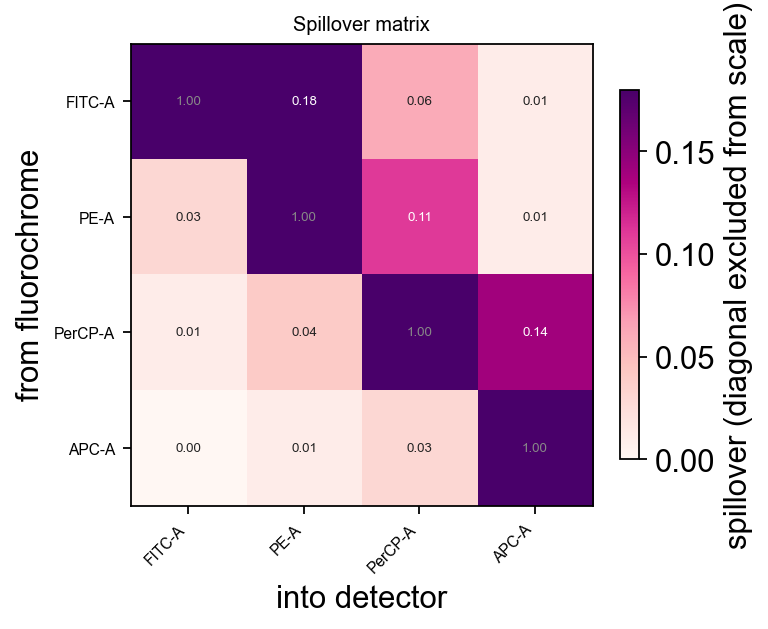

In [5]:
ov.flow.spillover_heatmap(adata)
None

## What spillover does to a plot

This is the part worth seeing rather than reading. Uncompensated, FITC (CD3)
leaking into the PE (CD4) detector produces a **diagonal smear**: every CD3+
event appears to be slightly CD4+, in exact proportion to how bright it is in
CD3. It looks exactly like a real population of double-positive cells, and it
is not one.

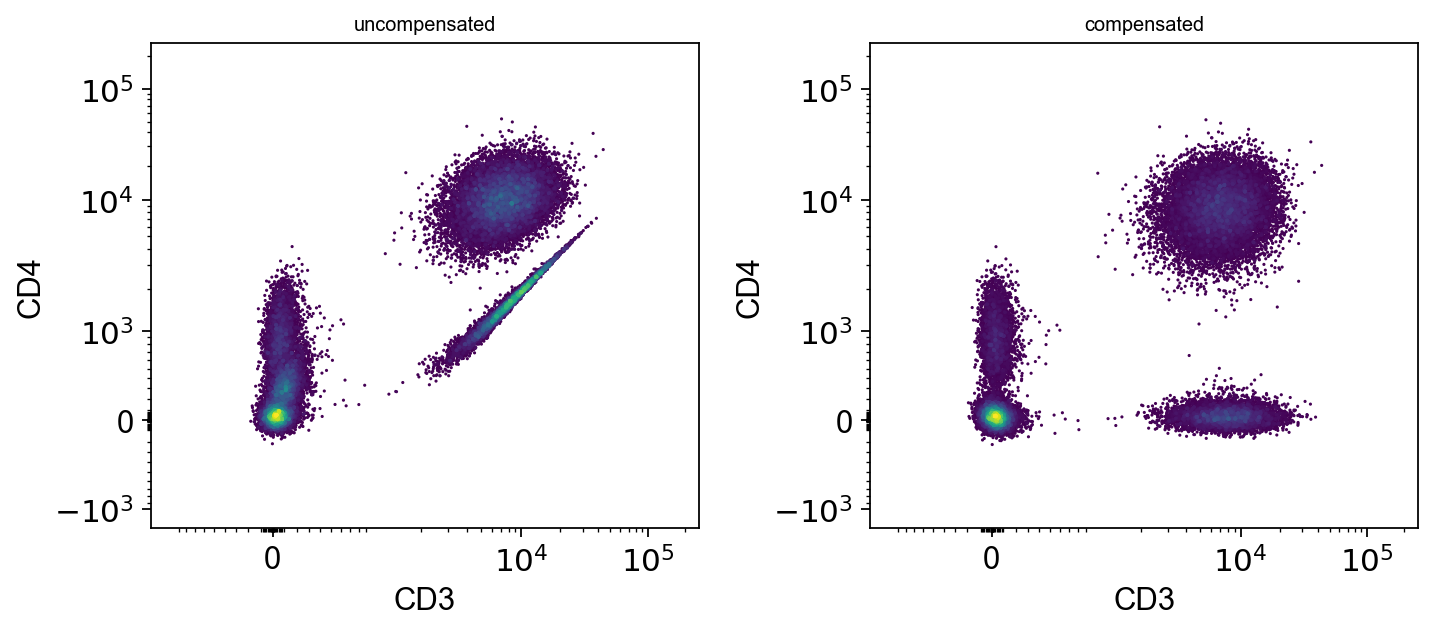

In [6]:
import matplotlib.pyplot as plt

lg = ov.flow.Logicle(t=262144.0, m=4.5, w=1.0, a=0.0)

raw = adata.copy()          # keep an uncompensated copy for the comparison
ov.flow.compensate(adata)   # uses uns['fcs']['spillover'] — the file's own matrix

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))
ov.flow.biaxial(raw,   "CD3", "CD4", transforms={"CD3": lg, "CD4": lg},
                ax=axes[0], title="uncompensated", max_events=40000)
ov.flow.biaxial(adata, "CD3", "CD4", transforms={"CD3": lg, "CD4": lg},
                ax=axes[1], title="compensated", max_events=40000)
plt.tight_layout()

The smear collapses into a horizontal population sitting at zero CD4 —
which is what CD3+CD8+ T cells actually are.

The same thing as a number, on populations that are genuinely CD3-negative and
therefore cannot be CD4-bright:

In [7]:
import numpy as np

cd3_negative = adata.obs["population"].isin(["B", "debris", "mono"]).to_numpy()
i_cd4 = list(adata.var.index).index("CD4")

print(f"CD4 median in CD3-negative populations")
print(f"  uncompensated : {np.median(raw.X[cd3_negative, i_cd4]):7.0f}")
print(f"  compensated   : {np.median(adata.X[cd3_negative, i_cd4]):7.0f}")

CD4 median in CD3-negative populations
  uncompensated :     188
  compensated   :      53


`compensate` records what it did in `uns['flow']` and keeps the
original matrix as a layer, so the operation is auditable and cannot silently
happen twice.

In [8]:
print(adata.uns["flow"]["compensated"], "|", list(adata.layers))
try:
    ov.flow.compensate(adata)
except Exception as e:
    print(f"{type(e).__name__}: {e}")

True | ['uncompensated']
ValueError: this object is already compensated. Compensating twice is silently destructive — the numbers stay plausible — so it has to be explicit: re-read the file if you meant to apply a different matrix.


## Display scales

Compensation is arithmetic; the *display scale* is what you look at. And a
compensated channel contains negative values — subtracting spillover from a dim
event routinely lands below zero, and so does the detector's own noise:

In [9]:
cd3 = adata[:, "CD3"].X.ravel()
print(f"CD3 events at or below zero: {(cd3 <= 0).sum():,} / {cd3.size:,} "
      f"({(cd3 <= 0).mean():.1%})")
print(f"minimum value: {cd3.min():.0f}")

CD3 events at or below zero: 6,784 / 59,600 (11.4%)
minimum value: -189


That single number rules out a log axis: `log10` of a negative number
does not exist, so **11% of the events would silently vanish** — including
exactly the dim events a threshold gate has to be drawn between.

A *biexponential* scale — logicle, hyperlog — is linear near zero and
logarithmic away from it, so it displays the whole range on one axis. Compare
the three on the same channel:

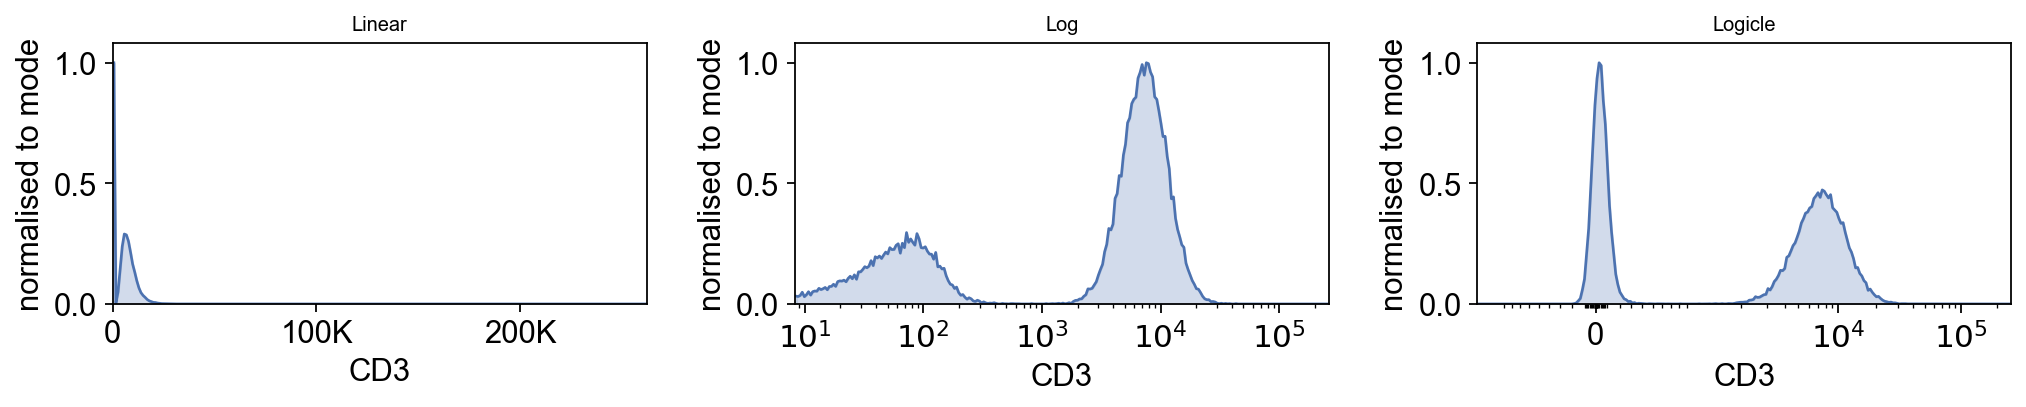

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8))
for ax, tr, name in zip(
        axes,
        [ov.flow.Linear(t=262144.0), ov.flow.Log(t=262144.0, m=4.5), lg],
        ["Linear", "Log", "Logicle"]):
    ov.flow.histogram(adata, "CD3", transforms={"CD3": tr}, ax=ax, title=name)
plt.tight_layout()

Linear crushes four decades of biology into the left edge. Log spreads
the positives out but cannot represent the negative population at all — that
peak is simply gone. Logicle keeps both.

### The `W` parameter is the whole decision

`W` sets how wide the linear region is, in decades. Too small and the negative
population is compressed into a spike at the axis edge; too large and the
positives lose resolution. It is the one logicle parameter worth tuning by
eye — which means looking at it:

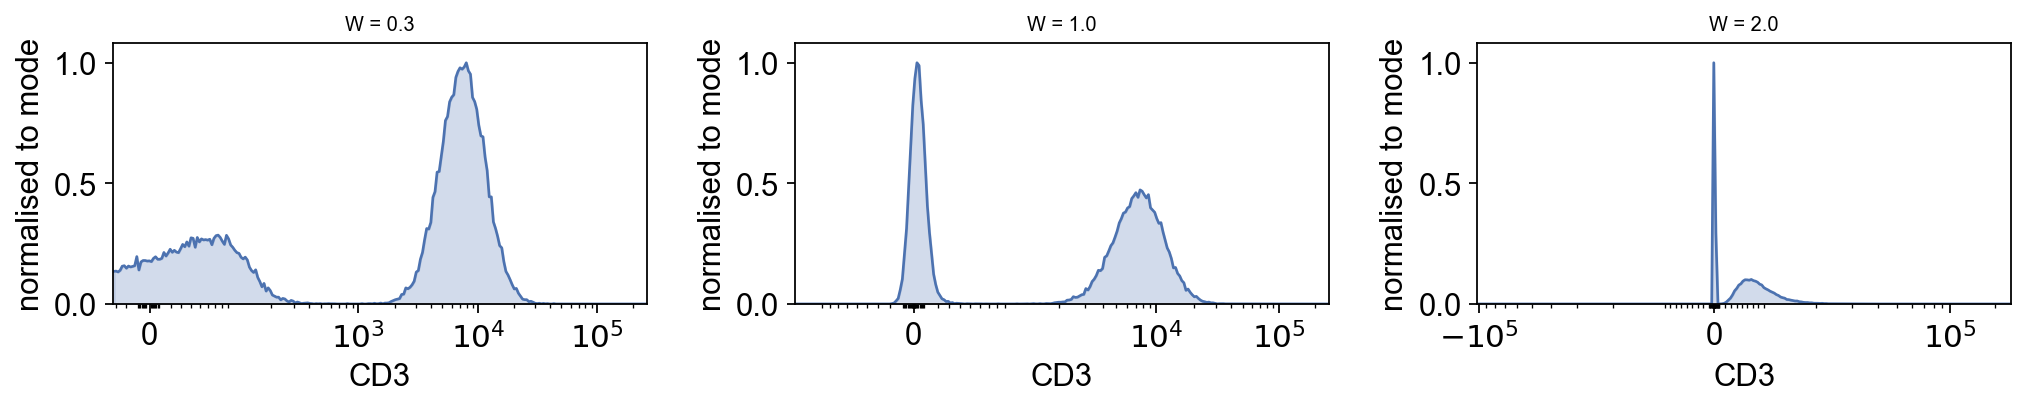

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.8))
for ax, w in zip(axes, [0.3, 1.0, 2.0]):
    tr = ov.flow.Logicle(t=262144.0, m=4.5, w=w, a=0.0)
    ov.flow.histogram(adata, "CD3", transforms={"CD3": tr}, ax=ax,
                      title=f"W = {w}")
plt.tight_layout()

A transform is a serialisable object, not a function, precisely so it
can be stored next to the gate whose boundary was drawn on it:

In [12]:
lg.to_dict()

{'type': 'logicle', 't': 262144.0, 'w': 1.0, 'm': 4.5, 'a': 0.0}

## What is next

The gate is where all of this is going. A polygon drawn on a logicle axis and
the same vertices read as linear values describe completely different
populations — so in [the next notebook](t_flow_02_gating.ipynb) every gate
carries the transform it was drawn on.